## Importing Libraries

In [1]:
import pandas as pd
import sklearn
import sys
from os import listdir
import matplotlib as mpl
import os
from matplotlib import image
from matplotlib import pyplot as plt
import h5py
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np
import tensorflow as tf
from tensorflow import keras as K
import pennylane as qml
from timeit import default_timer as timer
from datetime import timedelta
import seaborn as sns
from datetime import datetime, timedelta
import random
from tqdm.notebook import trange

## Information

In [2]:
path = 'brainTumorDataPublic/1.mat'

f = h5py.File(path, 'r')
label = f['cjdata']['label'][0][0]
pid = f['cjdata']['PID'][0]
image = f['cjdata']['image']
tumor_border = f['cjdata']['tumorBorder'][0]
tumor_mask = f['cjdata']['tumorMask']

print('Label:', label)
print('Patient ID:', pid)
print('Image shape:', image.shape)
print('Tumor border:', tumor_border)
print('Tumor mask shape:', tumor_mask.shape)

Label: 1.0
Patient ID: [49]
Image shape: (512, 512)
Tumor border: [267.61524501 231.37568058 277.83666062 248.10163339 289.91651543
 250.8892922  305.71324864 253.676951   318.72232305 249.9600726
 321.50998185 237.88021779 354.96188748 234.16333938 367.97096189
 227.65880218 380.9800363  210.93284936 372.61705989 195.13611615
 363.32486388 177.48094374 350.31578947 176.55172414 336.37749546
 183.98548094 317.79310345 196.06533575 305.71324864 207.21597096
 295.49183303 217.43738657 288.98729583 222.08348457 273.19056261
 223.94192377 268.54446461 228.58802178]
Tumor mask shape: (512, 512)


## Getting all the data and total number of labels

In [3]:
folder = "brainTumorDataPublic/" 
directs = sorted(os.listdir(folder))
labels = [np.array(h5py.File(f"{folder}{file}", 'r').get("cjdata/label"))[0][0] for file in directs]
labels = pd.Series(labels)
print(f"Number of labels: {labels.shape[0]}")

Number of labels: 3064


## Saving the Data to a txt file

In [4]:
num_files = sum(1 for filename in os.listdir(folder) if filename.endswith('.mat'))

with open('data.txt', 'w') as file:

    with trange(num_files, desc="Saving data to txt file") as pbar:

        for filename in os.listdir(folder):

            if filename.endswith('.mat'):

                path = os.path.join(folder, filename)
                f = h5py.File(path, 'r')
                label = f['cjdata']['label'][0][0]
                pid = f['cjdata']['PID'][0]
                image = f['cjdata']['image']
                tumor_border = f['cjdata']['tumorBorder'][0]
                tumor_mask = f['cjdata']['tumorMask']

                file.write(f'Filename: {filename}\n')
                file.write(f'Label: {label}\n')
                file.write(f'Patient ID: {pid}\n')
                file.write(f'Image shape: {image.shape}\n')
                file.write(f'Tumor border: {tumor_border}\n')
                file.write(f'Tumor mask shape: {tumor_mask.shape}\n')
                file.write('\n')

            pbar.update(1)

print('Done saving data to txt file.😊')

Saving data to txt file:   0%|          | 0/3064 [00:00<?, ?it/s]

Done saving data to txt file.😊


## Plotting the data

In [5]:
names = ["meningioma", "glioma", "pituitary tumor"]
labelcounts = labels.value_counts().sort_index()
labelcounts.index = names

print(labelcounts)

meningioma          708
glioma             1426
pituitary tumor     930
Name: count, dtype: int64


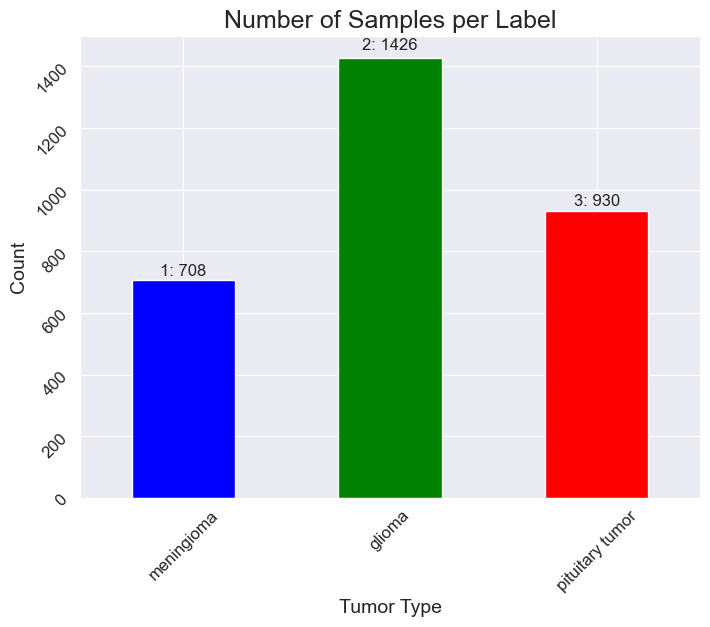

In [6]:
sns.set_style('darkgrid')

ax = labelcounts.plot(kind='bar', figsize=(8, 6), width=0.5, color=['blue', 'green', 'red'])

ax.set_title('Number of Samples per Label', fontsize=18)
ax.set_xlabel('Tumor Type', fontsize=14)
ax.set_ylabel('Count', fontsize=14)

ax.tick_params(labelsize=12, rotation=45)

for i, p in enumerate(ax.patches):
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    ax.annotate(f"{i+1}: {height}", (x + width/2, y + height*1.02), ha='center', fontsize=12)

plt.show()

## Plotting the image

In [7]:
labels = []
images = []
masks = []

for file in directs:
    f = h5py.File(folder+file, 'r')
    
    label = np.array(f.get('cjdata/label'))[0][0]
    
    if label not in labels:
        labels.append(label)
        
        img = np.stack((np.array(f.get('cjdata/image')),)*4, axis=-1)
        images.append(img)
        
        mask = np.array(f.get('cjdata/tumorMask'))
        masks.append(mask)

labels = np.asarray(labels)
images = np.asarray(images)
masks = np.asarray(masks)

print(f'Labels shape: {labels.shape}')
print(f'Images shape: {images.shape}')
print(f'Masks shape: {masks.shape}')

Labels shape: (3,)
Images shape: (3, 512, 512, 4)
Masks shape: (3, 512, 512)


In [8]:
b = K.utils.to_categorical(masks, num_classes=4).astype(np.uint8)

tumor = np.zeros_like(images[:, :, :, 1:])

image_norm = cv2.normalize(images[:, :, :, 0], None, alpha=0, beta=255,
                           norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F).astype(np.uint8)

print(f'Normalized image shape: {image_norm.shape}')

tumor[:, :, :, 0] = image_norm * (b[:, :, :, 0])
tumor[:, :, :, 1] = image_norm * (b[:, :, :, 0])
tumor[:, :, :, 2] = image_norm * (b[:, :, :, 0])

tumor += b[:, :, :, 1:] * 255

print(f'Tumor shape: {tumor.shape}')

Normalized image shape: (3, 512, 512)
Tumor shape: (3, 512, 512, 3)


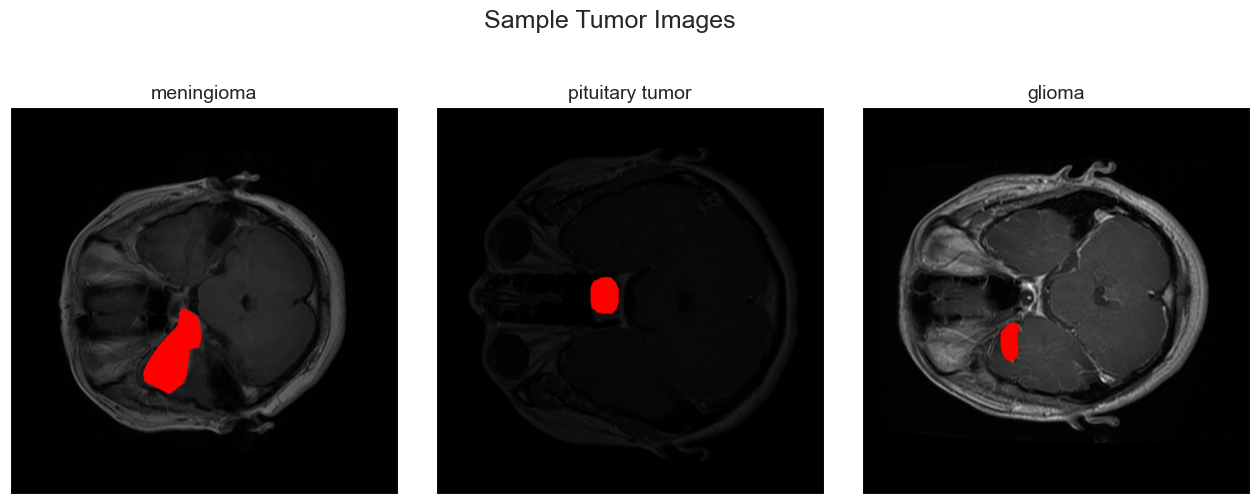

In [9]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(16, 6))

for i in range(3):
    ax[i].imshow(tumor[i], cmap='gray')
    
    ax[i].set_title(names[int(labels[i]-1)], fontsize=14)
    
    ax[i].set_xticks([])
    ax[i].set_yticks([])

fig.suptitle('Sample Tumor Images', fontsize=18)

fig.subplots_adjust(wspace=0.1)

plt.savefig('Images/sample_tumor_images.png')

plt.show()

## Quantum Convolution Node
    

In [10]:
wires= 4

dev4 = qml.device("default.qubit", wires=wires) 

@qml.qnode(dev4)

def CONV(phi, wires, i=0):
    theta = np.pi / 2

    qml.RX(phi[0] * np.pi, wires=0)
    qml.RX(phi[1] * np.pi, wires=1)
    qml.RX(phi[2] * np.pi, wires=2)
    qml.RX(phi[3] * np.pi, wires=3)

    qml.CRZ(theta, wires=[1, 0])
    qml.CRZ(theta, wires=[3, 2])
    qml.CRX(theta, wires=[1, 0])
    qml.CRX(theta, wires=[3, 2])
    qml.CRZ(theta, wires=[2, 0])
    qml.CRX(theta, wires=[2, 0])

    measurement = qml.expval(qml.PauliZ(wires=0))

    return measurement

## Quantum Convolutional Layer

In [11]:
def QCONV1(Img, image_number, image_total, step=2):
    
    H, W = Img.shape
    step2 = 2
    out = np.zeros(((H//step), (W//step)))
    
    with trange((H//step)*(W//step), desc="Processing image "+str(image_number)+"/"+str(image_total)) as pbar:
        for i in range(0, W, step):
            for j in range(0, H, step):
                phi = Img[i:i+2, j:j+2].flatten()
                measurement = CONV(phi, len(phi))
                out[i//step, j//step] = measurement
                pbar.update(1)

    return out

## Visualizing the Quantum Convolutional Circuit

In [12]:
phi = [1, 1, 1, 1]

drawer = qml.draw(CONV)

print("Circuit for phi = [1, 1, 1, 1] with 4 qubits:")
print("```")
print(drawer(phi, 4))
print("```")

Circuit for phi = [1, 1, 1, 1] with 4 qubits:
```
0: ──RX(3.14)─╭RZ(1.57)─╭RX(1.57)─╭RZ(1.57)─╭RX(1.57)─┤  <Z>
1: ──RX(3.14)─╰●────────╰●────────│─────────│─────────┤     
2: ──RX(3.14)─╭RZ(1.57)─╭RX(1.57)─╰●────────╰●────────┤     
3: ──RX(3.14)─╰●────────╰●────────────────────────────┤     
```


## Applying the Quantum Convolutional Layer to the Input Images

In [13]:
processFolder = 'Resize/'

start = timer()

w = 512
step = 2

k = 0
directs = sorted(listdir(folder))

for file in directs:
    all64 = sorted(listdir(processFolder))
    if file+".npz" in all64:
        continue
    
    f = h5py.File(folder+file, 'r')
    img = np.array(f.get("cjdata/image"))
    if img.shape[0] < 512:
        continue
    label = np.array(f.get("cjdata/label"))[0][0]

    scale_percent = 25
    width = int(img.shape[1] * scale_percent / 100)
    height = int(img.shape[0] * scale_percent / 100)
    dim = (width, height)
    resized = cv2.resize(img, dim, interpolation = cv2.INTER_AREA)
    NorImages = resized/255

    processed = QCONV1(NorImages, str(k)+" "+file, (len(directs)-len(all64)), step)

    np.savez_compressed(processFolder+file, image=processed, label=label)
    k+=1

end = timer()
time = (end - start)
execution_time = str(timedelta(seconds=round(time)))

formatted_time = datetime.strptime(execution_time, '%H:%M:%S').strftime('%H:%M:%S')

print("Execution time: " + formatted_time + " 👀")

Execution time: 00:00:06 👀


## Visualizing image after applying quantum convolutional layer

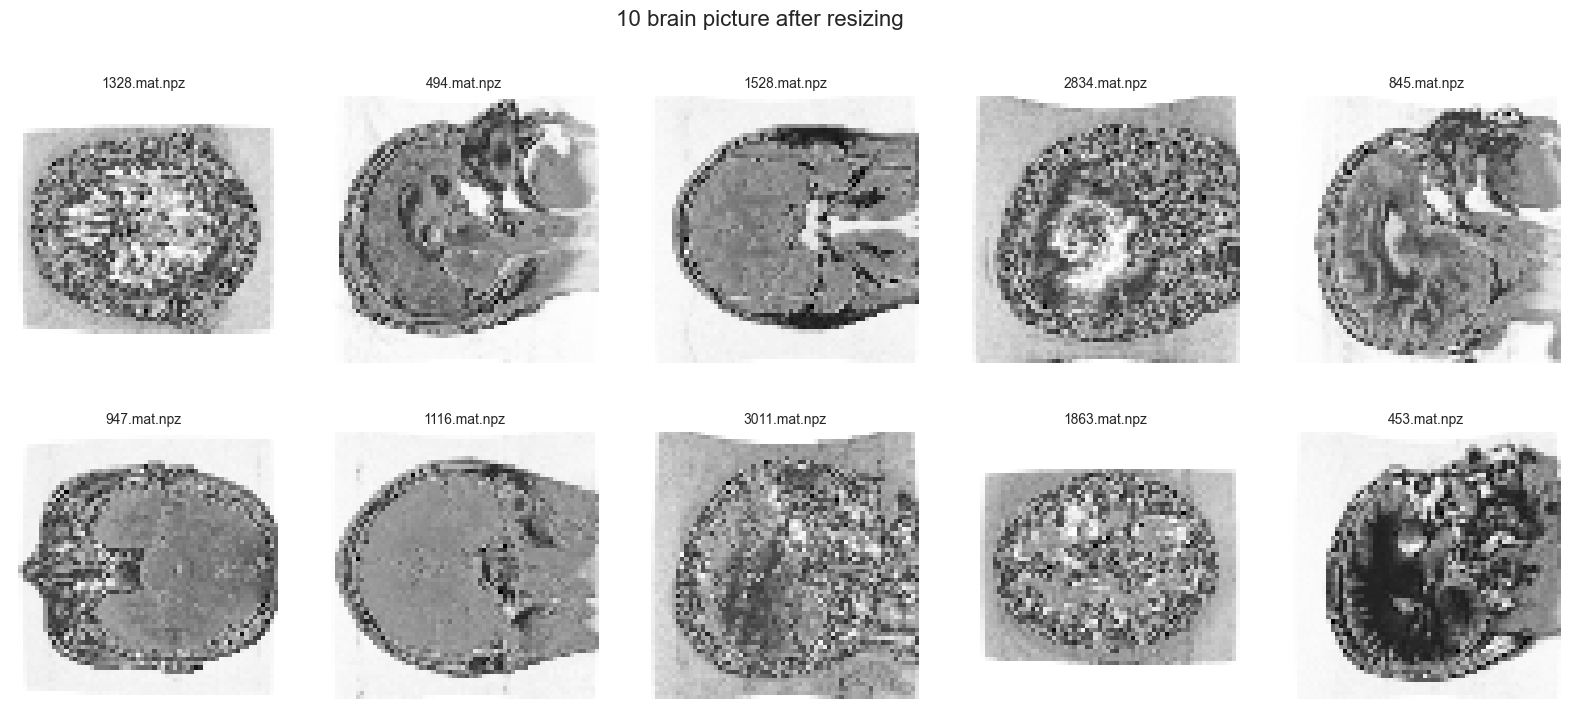

In [14]:
directory = "Resize/"

files = os.listdir(directory)

random_files = random.sample(files, 10)

fig, axs = plt.subplots(2, 5, figsize=(20, 8))

for i, file in enumerate(random_files):
    img = np.load(directory + file)['image']
    
    row = i // 5
    col = i % 5
    axs[row, col].imshow(img, cmap="gray")
    axs[row, col].axis("off")
    axs[row, col].set_title(file, fontsize=10)

fig.suptitle("10 brain picture after resizing", fontsize=16)

plt.savefig("Images/10_brain_picture_after_resizing.png", bbox_inches="tight")

## Labeling the images

npimages shape: (3049, 64, 64, 1)
nplabels shape: (3049,)
Image 1:


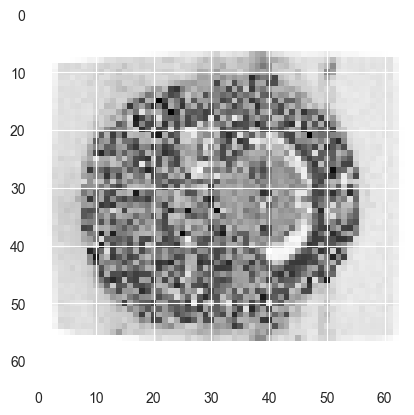

Label: 1.0

Image 2:


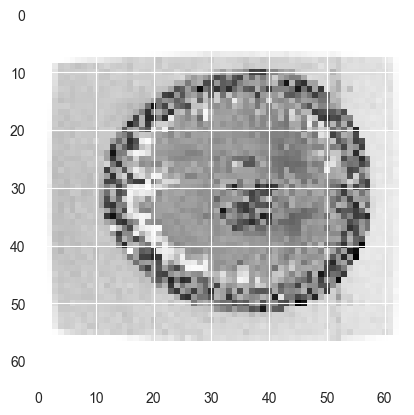

Label: 1.0

Image 3:


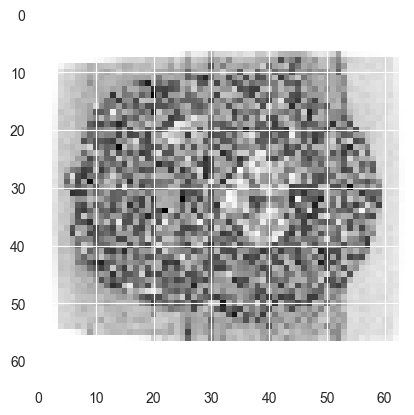

Label: 1.0

Image 4:


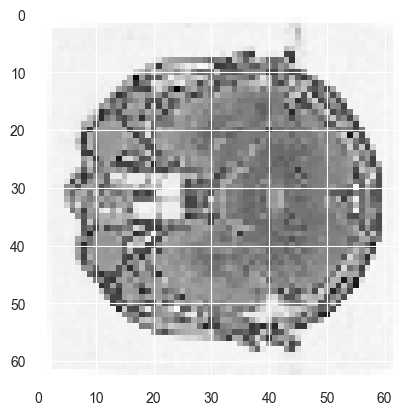

Label: 3.0

Image 5:


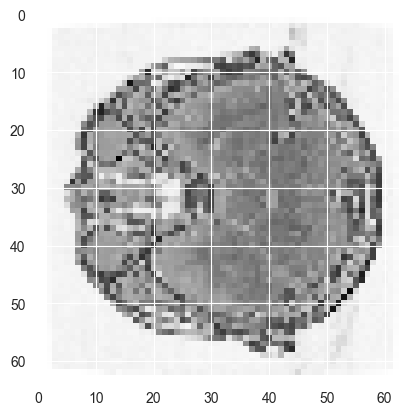

Label: 3.0



In [15]:
folder = "Resize/"

directs = sorted(listdir(folder))

images = []
masks = []
labels = []

for file in directs:
    try:
        data = np.load(folder + file)
        
        label = data["label"]
        img = np.stack((data["image"],), axis=-1)
        
        images.append(img)
        labels.append(label)
    except:
        continue

npimages = np.asarray(images)
nplabels = np.asarray(labels)

print(f"npimages shape: {npimages.shape}")
print(f"nplabels shape: {nplabels.shape}")

for i in range(5):
    print(f"Image {i+1}:")
    plt.imshow(npimages[i], cmap="gray")
    plt.show()
    print(f"Label: {nplabels[i]}")
    print()

## splitting the processed data into training, validation, and test

In [16]:
X_train, X_test, y_train, y_test = train_test_split(npimages, nplabels,
                                                    test_size=0.3,
                                                    random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_test, y_test,
                                                    test_size=0.5,
                                                    random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_valid shape: {X_valid.shape}")
print(f"y_valid shape: {y_valid.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (2134, 64, 64, 1)
y_train shape: (2134,)
X_valid shape: (457, 64, 64, 1)
y_valid shape: (457,)
X_test shape: (458, 64, 64, 1)
y_test shape: (458,)


## Creating the Quantum model

In [17]:
def Enhanced_Quantum_Model():
    model = K.models.Sequential([
        K.layers.Flatten(),
        K.layers.BatchNormalization(),
        
        K.layers.Dense(256, kernel_initializer='he_uniform'),
        K.layers.LeakyReLU(alpha=0.1),
        K.layers.BatchNormalization(),
        K.layers.Dropout(0.3),
        
        K.layers.Dense(128, kernel_initializer='he_uniform'),
        K.layers.LeakyReLU(alpha=0.1),
        K.layers.BatchNormalization(),
        K.layers.Dropout(0.2),
        
        K.layers.Dense(4, activation="softmax")
    ])
    
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.001,
        decay_steps=1000,
        decay_rate=0.9
    )
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    
    return model

## Training the model

In [18]:
y_train_adjusted = y_train - 1
y_valid_adjusted = y_valid - 1

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.experimental.preprocessing.RandomFlip("horizontal"),
    tf.keras.layers.experimental.preprocessing.RandomRotation(0.1),
])

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True
)

checkpoint_path = "checkpoints/enhanced_quantum.ckpt"
checkpoint_dir = os.path.dirname(checkpoint_path)
os.makedirs(checkpoint_dir, exist_ok=True)

cp_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=True,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True
)

q_model_enhanced = Enhanced_Quantum_Model()

q_history_enhanced = q_model_enhanced.fit(
    X_train,
    y_train_adjusted,
    validation_data=(X_valid, y_valid_adjusted),
    batch_size=32, 
    epochs=50,      
    verbose=1,
    callbacks=[cp_callback, early_stopping]
)

Epoch 1/50
67/67 [==============================] - 4s 21ms/step - loss: 0.6879 - accuracy: 0.7784 - val_loss: 0.7830 - val_accuracy: 0.6477
Epoch 2/50
67/67 [==============================] - 1s 13ms/step - loss: 0.3263 - accuracy: 0.8889 - val_loss: 0.6235 - val_accuracy: 0.7396
Epoch 3/50
67/67 [==============================] - 1s 14ms/step - loss: 0.1955 - accuracy: 0.9367 - val_loss: 0.5092 - val_accuracy: 0.7659
Epoch 4/50
67/67 [==============================] - 1s 13ms/step - loss: 0.1491 - accuracy: 0.9508 - val_loss: 0.3595 - val_accuracy: 0.8556
Epoch 5/50
67/67 [==============================] - 1s 13ms/step - loss: 0.1150 - accuracy: 0.9644 - val_loss: 0.3242 - val_accuracy: 0.8906
Epoch 6/50
67/67 [==============================] - 1s 14ms/step - loss: 0.0951 - accuracy: 0.9644 - val_loss: 0.2658 - val_accuracy: 0.9147
Epoch 7/50
67/67 [==============================] - 1s 11ms/step - loss: 0.0831 - accuracy: 0.9733 - val_loss: 0.3100 - val_accuracy: 0.9125
Epoch 8/50
67

## Save the model

In [19]:
q_model_enhanced.save('QModel.h5')

## Plot the results

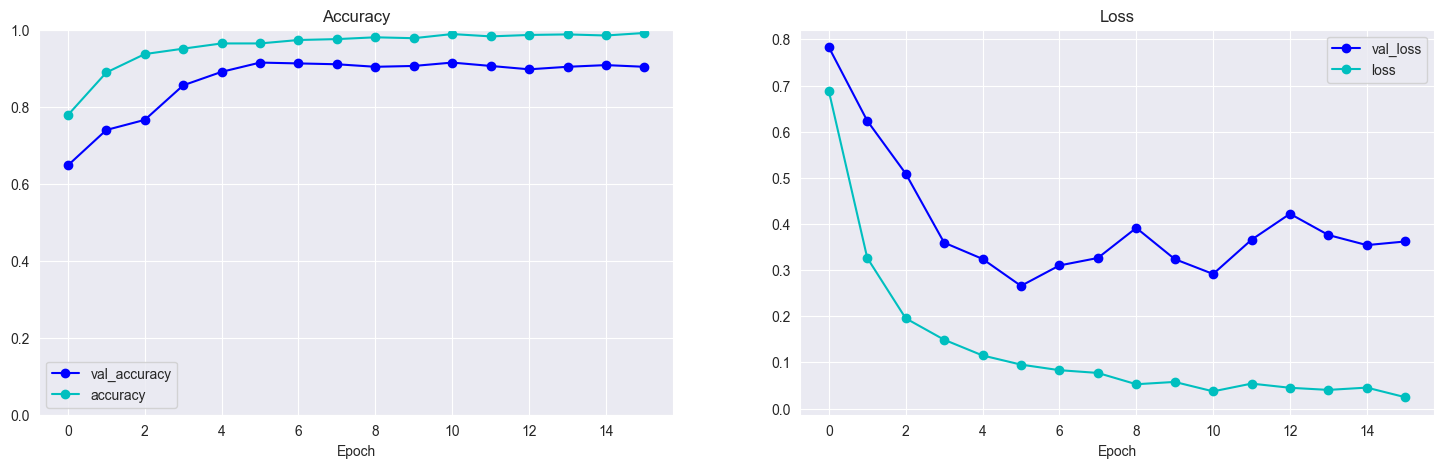

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))

ax1.plot(q_history_enhanced.history["val_accuracy"], "-ob", label="val_accuracy")
ax1.plot(q_history_enhanced.history["accuracy"], "-oc", label="accuracy")
ax1.set_ylim([0, 1])
ax1.set_title("Accuracy")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(q_history_enhanced.history["val_loss"], "-ob", label="val_loss")
ax2.plot(q_history_enhanced.history["loss"], "-oc", label="loss")
ax2.set_title("Loss")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.savefig("Images/plot_QModel.png")

plt.show()

## Average accuracy

In [21]:
avg_accuracy = sum(q_history_enhanced.history["accuracy"]) / len(q_history_enhanced.history["accuracy"])

avg_accuracy_percent = avg_accuracy * 100

print(f"Average accuracy: {avg_accuracy_percent:.2f}%")

Average accuracy: 95.71%


## Highest accuracy

In [22]:
highest_accuracy = max(q_history_enhanced.history["accuracy"])
highest_accuracy_percent = highest_accuracy * 100
print(f"Highest accuracy: {highest_accuracy_percent:.2f}%")

Highest accuracy: 99.16%


## Getting the confusion matrix

In [23]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.rcParams['axes.facecolor'] = '#f7f7f7'

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)

    cbar = ax.figure.colorbar(im, ax=ax)

    ax.set_xticks(np.arange(len(classes)))
    ax.set_yticks(np.arange(len(classes)))
    ax.set_xticklabels(classes, fontsize=14, color='#333333')
    ax.set_yticklabels(classes, fontsize=14, color='#333333')

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontsize=16)

    ax.set_title(title, fontsize=18, color='#333333')
    ax.set_xlabel('Predicted label', fontsize=16, color='#333333')
    ax.set_ylabel('True label', fontsize=16, color='#333333')

    cbar.ax.set_ylabel('Count', rotation=-90, va="bottom",
                       fontsize=14, color='#333333')

    fig.tight_layout()

    plt.savefig('Images/confusion_matrix_for_qmodel.png')
    
    plt.show()

## Loading the model

In [24]:
q_model = K.models.load_model('QModel.h5')

## Classification report

In [25]:
yhat = q_model.predict(X_test)
yhat = yhat.argmax(axis=1)

print('\n-----------------------Classification Report-----------------------\n')
print(classification_report(y_test, yhat))


15/15 [==============================] - 0s 4ms/step

-----------------------Classification Report-----------------------

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         0
         1.0       0.07      0.12      0.09       113
         2.0       0.00      0.00      0.00       213
         3.0       0.00      0.00      0.00       132

    accuracy                           0.03       458
   macro avg       0.02      0.03      0.02       458
weighted avg       0.02      0.03      0.02       458



C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565:

Confusion matrix, without normalization


<Figure size 600x600 with 0 Axes>

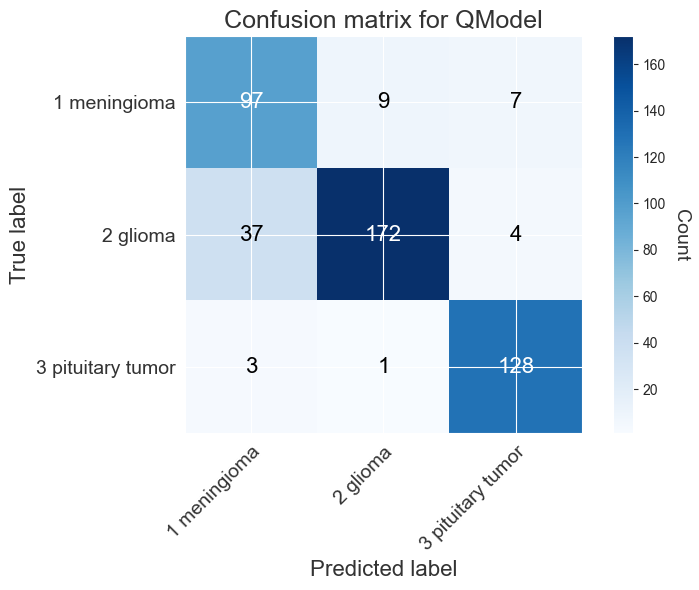

In [ ]:
cnf_matrix = tf.math.confusion_matrix(y_test, yhat)
np.set_printoptions(precision=2)

plt.figure(figsize=(6, 6))
plot_confusion_matrix(np.array(cnf_matrix[1:, 1:]), classes=['1 meningioma', '2 glioma', '3 pituitary tumor'], normalize=False,  title='Confusion matrix for QModel')


# CNN Model

In [26]:
def CCONV1(Img, image_number, image_total, step=2):
    """Classical equivalent of QCONV1"""
    H, W = Img.shape
    out = np.zeros(((H//step), (W//step)))
    
    with trange((H//step)*(W//step), desc="Processing image "+str(image_number)+"/"+str(image_total)) as pbar:
        for i in range(0, W, step):
            for j in range(0, H, step):
                block = Img[i:i+2, j:j+2].flatten()
                measurement = np.mean(block)
                out[i//step, j//step] = measurement
                pbar.update(1)

    return out

In [27]:
processFolder = 'Resize_Classical/'
os.makedirs(processFolder, exist_ok=True)

start = timer()

w = 512
step = 2

k = 0
directs = sorted(listdir("brainTumorDataPublic/"))

for file in directs:
    all64 = sorted(listdir(processFolder)) if os.path.exists(processFolder) else []
    if file+".npz" in all64:
        continue
    
    f = h5py.File("brainTumorDataPublic/"+file, 'r')
    img = np.array(f.get("cjdata/image"))
    if img.shape[0] < 512:
        continue
    label = np.array(f.get("cjdata/label"))[0][0]

    scale_percent = 25
    width = int(img.shape[1] * scale_percent / 100)
    height = int(img.shape[0] * scale_percent / 100)
    dim = (width, height)
    resized = cv2.resize(img, dim, interpolation = cv2.INTER_AREA)
    NorImages = resized/255

    processed = CCONV1(NorImages, str(k)+" "+file, (len(directs)-len(all64)), step)

    np.savez_compressed(processFolder+file, image=processed, label=label)
    k+=1

end = timer()
time = (end - start)
execution_time = str(timedelta(seconds=round(time)))

print("Execution time: " + execution_time)

Execution time: 0:00:07


## Splitting the data into training, validation, and testing sets

In [28]:
folder = processFolder
directs = sorted(listdir(folder))

images_classical = []
labels_classical = []

for file in directs:
    try:
        data = np.load(folder + file)
        
        label = data["label"]
        img = np.stack((data["image"],), axis=-1)
        
        images_classical.append(img)
        labels_classical.append(label)
    except:
        continue

npimages_classical = np.asarray(images_classical)
nplabels_classical = np.asarray(labels_classical)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    npimages_classical, nplabels_classical,
    test_size=0.3,
    random_state=42
)

X_valid_c, X_test_c, y_valid_c, y_test_c = train_test_split(
    X_test_c, y_test_c,
    test_size=0.5,
    random_state=42
)

In [ ]:
def Enhanced_Classical_Model():
    model = K.models.Sequential([
        K.layers.Flatten(),
        K.layers.BatchNormalization(),
        
        K.layers.Dense(512, kernel_initializer='he_uniform'),
        K.layers.LeakyReLU(alpha=0.1),
        K.layers.BatchNormalization(),
        K.layers.Dropout(0.3),
        
        K.layers.Dense(256, kernel_initializer='he_uniform'),
        K.layers.LeakyReLU(alpha=0.1),
        K.layers.BatchNormalization(),
        K.layers.Dropout(0.2),
        
        K.layers.Dense(128, kernel_initializer='he_uniform'),
        K.layers.LeakyReLU(alpha=0.1),
        K.layers.BatchNormalization(),
        K.layers.Dropout(0.1),
        
        K.layers.Dense(4, activation="softmax")
    ])
    
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.001,
        decay_steps=1000,
        decay_rate=0.9
    )
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    
    return model
c_model = Enhanced_Classical_Model()

In [30]:
y_train_c_adjusted = y_train_c - 1
y_valid_c_adjusted = y_valid_c - 1
y_test_c_adjusted = y_test_c - 1

In [32]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True
)

checkpoint_path = "checkpoints/enhanced_classical.ckpt"
checkpoint_dir = os.path.dirname(checkpoint_path)
os.makedirs(checkpoint_dir, exist_ok=True)

cp_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=True,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True
)

c_history = c_model.fit(
    X_train_c,
    y_train_c_adjusted,  # Use adjusted labels
    validation_data=(X_valid_c, y_valid_c_adjusted),
    batch_size=32,
    epochs=50,
    verbose=1,
    callbacks=[cp_callback, early_stopping]
)

c_model.save('CModel.h5')

Epoch 1/50
67/67 [==============================] - 4s 33ms/step - loss: 0.7804 - accuracy: 0.7320 - val_loss: 2.7789 - val_accuracy: 0.6980
Epoch 2/50
67/67 [==============================] - 2s 28ms/step - loss: 0.4421 - accuracy: 0.8388 - val_loss: 0.6772 - val_accuracy: 0.7834
Epoch 3/50
67/67 [==============================] - 2s 28ms/step - loss: 0.3682 - accuracy: 0.8669 - val_loss: 0.5118 - val_accuracy: 0.8359
Epoch 4/50
67/67 [==============================] - 2s 27ms/step - loss: 0.2628 - accuracy: 0.9007 - val_loss: 0.3935 - val_accuracy: 0.8425
Epoch 5/50
67/67 [==============================] - 2s 27ms/step - loss: 0.2616 - accuracy: 0.9100 - val_loss: 0.4323 - val_accuracy: 0.8578
Epoch 6/50
67/67 [==============================] - 2s 26ms/step - loss: 0.2331 - accuracy: 0.9199 - val_loss: 0.6349 - val_accuracy: 0.8403
Epoch 7/50
67/67 [==============================] - 2s 27ms/step - loss: 0.2172 - accuracy: 0.9278 - val_loss: 0.2413 - val_accuracy: 0.9037
Epoch 8/50
67

## Plotting the results

C:\Users\USER\AppData\Local\Temp\ipykernel_1580\3049270032.py:4: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-or" (-> linestyle='-'). The keyword argument will take precedence.
  ax1.plot(c_history.history["accuracy"], "-or", linestyle='--', label="classical accuracy")
C:\Users\USER\AppData\Local\Temp\ipykernel_1580\3049270032.py:6: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-ob" (-> linestyle='-'). The keyword argument will take precedence.
  ax1.plot(q_history_enhanced.history["accuracy"], "-ob", linestyle='--', label="quantum accuracy")
C:\Users\USER\AppData\Local\Temp\ipykernel_1580\3049270032.py:13: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-or" (-> linestyle='-'). The keyword argument will take precedence.
  ax2.plot(c_history.history["loss"], "-or", linestyle='--', label="classical loss")
C:\Users\USER\Ap

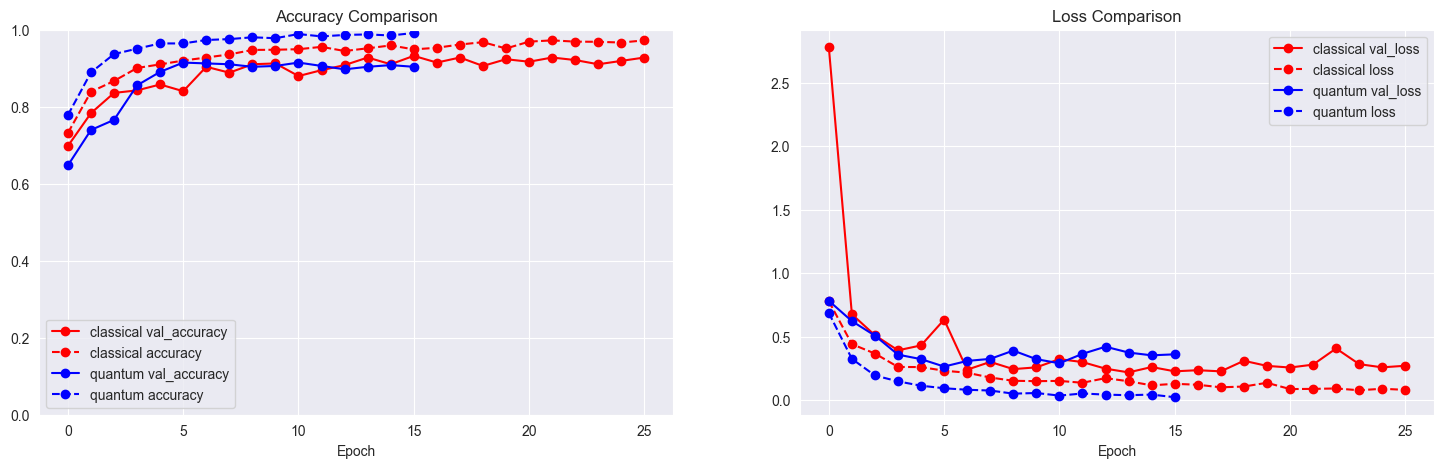

Classical model highest accuracy: 97.24%
Quantum model highest accuracy: 99.16%
Classical model average accuracy: 93.42%
Quantum model average accuracy: 95.71%


In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))

ax1.plot(c_history.history["val_accuracy"], "-or", label="classical val_accuracy")
ax1.plot(c_history.history["accuracy"], "-or", linestyle='--', label="classical accuracy")
ax1.plot(q_history_enhanced.history["val_accuracy"], "-ob", label="quantum val_accuracy")
ax1.plot(q_history_enhanced.history["accuracy"], "-ob", linestyle='--', label="quantum accuracy")
ax1.set_ylim([0, 1])
ax1.set_title("Accuracy Comparison")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(c_history.history["val_loss"], "-or", label="classical val_loss")
ax2.plot(c_history.history["loss"], "-or", linestyle='--', label="classical loss")
ax2.plot(q_history_enhanced.history["val_loss"], "-ob", label="quantum val_loss")
ax2.plot(q_history_enhanced.history["loss"], "-ob", linestyle='--', label="quantum loss")
ax2.set_title("Loss Comparison")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.savefig("Images/quantum_vs_classical_comparison.png")
plt.show()

c_highest_acc = max(c_history.history["accuracy"]) * 100
q_highest_acc = max(q_history_enhanced.history["accuracy"]) * 100

c_avg_acc = (sum(c_history.history["accuracy"]) / len(c_history.history["accuracy"])) * 100
q_avg_acc = (sum(q_history_enhanced.history["accuracy"]) / len(q_history_enhanced.history["accuracy"])) * 100

print(f"Classical model highest accuracy: {c_highest_acc:.2f}%")
print(f"Quantum model highest accuracy: {q_highest_acc:.2f}%")
print(f"Classical model average accuracy: {c_avg_acc:.2f}%")
print(f"Quantum model average accuracy: {q_avg_acc:.2f}%")

## Load the classical model

In [35]:
model = K.models.load_model('CModel.h5')

In [36]:
yhat = model.predict(X_test_c)  
yhat = yhat.argmax(axis=1)

print('\n-----------------------Classification Report-----------------------\n')
print(classification_report(y_test_c, yhat))  

15/15 [==============================] - 0s 5ms/step

-----------------------Classification Report-----------------------

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         0
         1.0       0.06      0.12      0.08       113
         2.0       0.01      0.00      0.01       213
         3.0       0.00      0.00      0.00       132

    accuracy                           0.03       458
   macro avg       0.02      0.03      0.02       458
weighted avg       0.02      0.03      0.02       458



C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565:

## Getting the confusion matrix

In [37]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.rcParams['axes.facecolor'] = '#f7f7f7'

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)

    cbar = ax.figure.colorbar(im, ax=ax)

    ax.set_xticks(np.arange(len(classes)))
    ax.set_yticks(np.arange(len(classes)))
    ax.set_xticklabels(classes, fontsize=14, color='#333333')
    ax.set_yticklabels(classes, fontsize=14, color='#333333')

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontsize=16)

    ax.set_title(title, fontsize=18, color='#333333')
    ax.set_xlabel('Predicted label', fontsize=16, color='#333333')
    ax.set_ylabel('True label', fontsize=16, color='#333333')

    cbar.ax.set_ylabel('Count', rotation=-90, va="bottom",
                       fontsize=14, color='#333333')

    fig.tight_layout()

    plt.savefig('Images/confusion_matrix_for_Classical_model.png')
    
    plt.show()

Confusion matrix, without normalization


<Figure size 600x600 with 0 Axes>

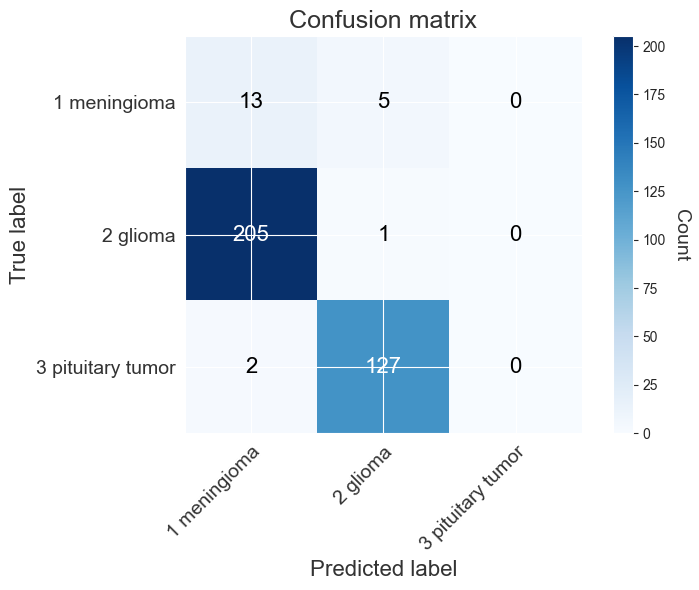

In [38]:
cnf_matrix = tf.math.confusion_matrix(y_test, yhat)
np.set_printoptions(precision=2)

plt.figure(figsize=(6, 6))
plot_confusion_matrix(np.array(cnf_matrix[1:, 1:]), classes=['1 meningioma', '2 glioma', '3 pituitary tumor'], normalize=False,  title='Confusion matrix')

## Versions of the used libraries 

In [39]:
PINK = '\033[95m'
BLUE = '\033[34m'
ENDC = '\033[m'

print(f"{PINK}Python version:   {ENDC}{sys.version.split()[0]}")
print(f"{BLUE}NumPy version:    {ENDC}{np.__version__}")
print(f"{PINK}Pandas version:   {ENDC}{pd.__version__}")
print(f"{BLUE}Matplotlib version:{ENDC}{mpl.__version__}")
print(f"{PINK}OpenCV version:   {ENDC}{cv2.__version__}")
print(f"{BLUE}Scikit-learn version:{ENDC}{sklearn.__version__}")
print(f"{PINK}TensorFlow version:{ENDC}{tf.__version__}")
print(f"{BLUE}Pennylane version:{ENDC}{qml.__version__}")

Python version:   3.11.9
NumPy version:    1.23.5
Pandas version:   2.2.3
Matplotlib version:3.10.1
OpenCV version:   4.10.0
Scikit-learn version:1.6.1
TensorFlow version:2.12.0
Pennylane version:0.40.0
